# <a id='toc1_'></a>[UMAP Detalhado](#toc0_)

## Sumário<a id='toc0_'></a>    
- [UMAP Detalhado](#toc1_)    
  - [Introdução](#toc1_2_)    
  - [Como funciona o UMAP](#toc1_3_)    
    - [Análise Topológica de Dados e Conjuntos Simpliciais](#toc1_3_1_)    
    - [Montando o Complexo Simplicial de um Conjunto de Dados](#toc1_3_2_)    
    - [Encontrando uma Representação de Baixa Dimensão](#toc1_3_3_)    
  - [Referências](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_2_'></a>[Introdução](#toc0_)

O objetivo principal desse notebook é apresentar ao leitor as motivações matemáticas por trás da construção do algoritmo UMAP. Espera-se que o leitor tenha um entendimento introdutório do algoritmo e seu funcionamento. Caso contrário, confira o notebook [00 - Visão Geral](00%20-%20Visão%20Geral.ipynb). Vale destacar que grande parte desse material é inspirado na explicação original do site oficial do UMAP [[1](#referencias)]

## <a id='toc1_3_'></a>[Como funciona o UMAP](#toc0_)

### <a id='toc1_3_1_'></a>[Análise Topológica de Dados e Conjuntos Simpliciais](#toc0_)

Antes de entender como funciona o UMAP, precisamos entender os seus fundamentos, e tudo inicia na **análise topológica de dados e conjuntos simpliciais*.

Um *simplexo* pode ser definido como a generalização de um triângulo em outras dimensões. Podemos entendê-lo como o polígono mais simples de sua dimensão. Em zero dimensões, ele seria um ponto (0-simplex); em uma, seria uma linha (1-simplex); em duas, um triângulo (2-simplex); em três, um tetraedro (3-simplex); e assim por diante. A forma matemática de descrever isso seria dizer que ele é **o invólucro convexo de (n+1) pontos independentes em $ℝ^n$** [[2](#referencias)]

<img src="../assets/simplexes.webp" width=700px id="simplexes"> <br/>
**Figura 1:** Representação ilustrativa de simplexos em diferentes dimensões.<br/>
<small>Fonte: UMAP DEVELOPERS [[1](#referencias)]</small>

Utilizando os simplexos como blocos de construção, podemos conectá-los de forma a construir espaços topológicos mais interessantes denominados **complexos simpliciais**. Podemos definir um complexo simplicial $S$ como **uma coleção finita de simplexos tais que cada face de um simplexo de $S$ é um simplexo de $S$ e a intersecção de dois simplexos de $S$ é vazia ou uma face de ambos.** [[3](#referencias)]

<img src="../assets/simplicial_complex.png" width=600px id="simplicial_complex"> <br/>
**Figura 2:** Representação ilustrativa de um complexo simplicial e uma coleção simplicial.<br/>
<small>Fonte: MCINNES, Leland [[1](#referencias)]</small>

### <a id='toc1_3_2_'></a>[Montando o Complexo Simplicial de um Conjunto de Dados](#toc0_)

O desafio que resta agora é descobrir como construir um complexo simplicial a partir de um espaço topológico qualquer. Para isso, podemos utilizar uma **cobertura aberta** do espaço para construir um **complexo de Čech**. De uma forma intuitiva, uma cobertura aberta de um determinado espaço topológico pode ser entendida como a família de conjuntos cuja união resulta no espaço inteiro, enquanto o complexo de Čech é uma forma combinatória de transformar isso em um complexo simplicial.

Parece complicado mas é um processo que pode ser explicado de forma simples: primeiro, consideramos cada conjunto da cobertura como um 0-simplex. quando dois conjuntos possuem uma interseção não nula, então desenhamos um 1-simplex entre eles. Se existir uma interseção tripla, então fazemos um 2-simplex. e assim por diante.

Pode parecer simples demais para funcionar, mas a teoria topológica por trás garante que esse processo pode representar o espaço de um jeito significante. O teorema principal por trás desse resultado é o [Teorema do Nervo](https://en.wikipedia.org/wiki/Nerve_complex), caso se interesse para saber mais. Vale ressaltar também que a qualidade da cobertura também importa, mas no geral é possível preservar grande parte da topologia.

Para entender como podemos montar essa cobertura em um espaço topológico a partir de um conjunto finito de dados, vamos montar um conjunto de dados sintético para ilustrar o conceito.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Polygon
from matplotlib.colors import Normalize
from ipywidgets import interact, IntSlider, FloatSlider
import numpy as np

%matplotlib inline

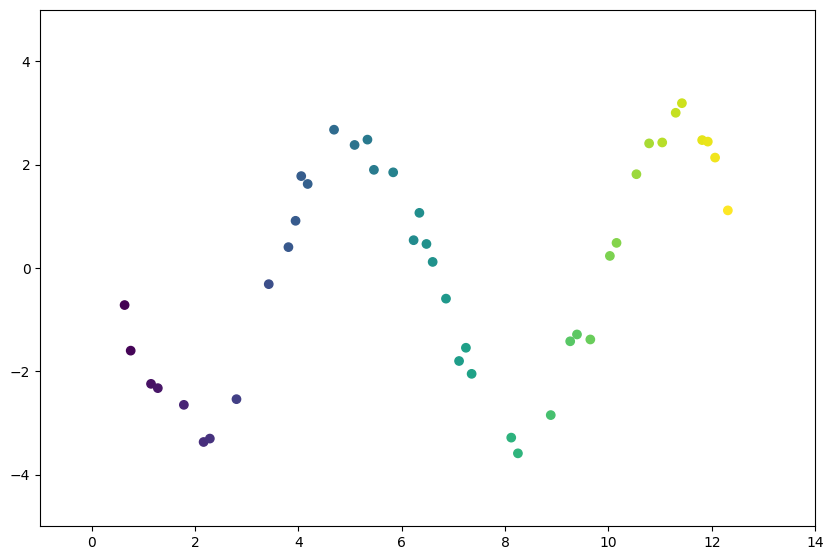

In [2]:
x = np.array([i + np.random.uniform(-0.01,0.01) for i in np.linspace(0, np.pi * 4, 100)])
x = np.delete(x, np.random.randint(0, len(x), 80))

y = np.array([i + np.random.normal(-0.1,0.1) for i in np.sin(x+np.random.uniform(-40,40))]) * 3
data = np.array([[x[i], y[i]] for i in range(len(x))])

cmap = plt.get_cmap("viridis")
norm = Normalize(0, 14)


plt.figure(figsize=(10, 7))

def plot_data():    
    plt.scatter(x, y, c=x)
        
    plt.ylim(-5, 5)
    plt.xlim(-1, 14)
    plt.gca().set_aspect("equal")
    plt.show()
    
plot_data()

Considerando que nosso espaço é métrico (ou seja, é possível calcular a distância entre dois pontos), podemos aproximar a cobertura definindo um raio fixo a partir de cada ponto e criando uma conexão caso os raios se econtrem, como no exemplo a seguir:

**Nota**: O código a seguir é apenas para fins didáticos, então não foi pensado para ser optimal.

In [ ]:
def plot_fixed_radius_cover(radius_size=5):
    plt.figure(figsize=(10, 7))
    
    for x, y in data:
        color = cmap(norm(x))
        
        circle = Circle((x, y), radius_size, color=color, alpha=0.2, ec=None)
        plt.gca().add_patch(circle)
        
        for xj, yj in data:
            if x == xj and y == yj:
                continue
            
            dist = np.sqrt((xj-x)**2 + (yj-y)**2)
            
            if dist > 2 * radius_size:
                continue
                
            line = Line2D([x, xj], [y, yj], color=color, alpha=0.4)
            plt.gca().add_line(line)
            
            for xk, yk in data:
                if x == xk and y == yk:
                    continue
                
                if xj == xk and yj == yk:
                    continue
                
                dist = np.sqrt((xk-x)**2 + (yk-y)**2)
                
                if dist > 2 * radius_size:
                    continue
                
                dist = np.sqrt((xk-xj)**2 + (yk-yj)**2)
                
                if dist > 2 * radius_size:
                    continue
                
                polygon = Polygon([[x, y], [xj, yj], [xk, yk]], closed=True, color=color, alpha=0.02, ec=None)
                plt.gca().add_patch(polygon)
                
                
    
    plot_data()
    
interact(
    plot_fixed_radius_cover,
    radius_size=FloatSlider(min=0.01, max=2, value=0.5, step=0.01)
);

interactive(children=(FloatSlider(value=0.5, description='radius_size', max=2.0, min=0.01, step=0.01), Output(…

Dessa forma, podemos representar o complexo simplicial formado por 0-, 1- e 2- simplexos como pontos, linhas e triângulos, observando como o complexo de Čech pode representar de forma adequada as relações de vizinhança. Os simplexos de mais dimensões podem ser difíceis de enxergar, mas a ideia segue a mesma.

Entretanto, podemos ver que pode ser difícil definir o melhor tamanho de raio para representar o nosso conjunto de dados. Se escolhermos um raio muito pequeno, iremos separar a cobertura em diversos fragmentos. Se escolhermos um raio muito grande, nosso complexo será formado por alguns objetos hiperdimensionais que pode não capturar a estrutura geral do espaço em análise.

Também é possível observar como em áreas mais densas, o complexo tende a formar simplexos de alta dimensão que não preservam a topologia dos dados, enquanto áreas mais esparsas a falta de cobertura pode resultar em muitas áreas disconectadas.

Isso seria resolvido se nosso conjunto tivesse dados uniformes perfeitamente espaçados, mas sabemos que isso nunca acontece com dados reais. Então, a solução proposta do UMAP é simples: vamos tratar os dados como se eles fossem uniformes. Nesse caso, o que vai variar seria as distâncias dentro do espaço topológico.2

A ideia principal é trocar o raio fixo por um raio que varia de acordo com as distâncias dos $k$ vizinhos mais próximos. Dessa forma, mantemos a estrutura topológica principal, realizando uma distorção que irá proporcionar uma cobertura melhor. A figura a seguir ilustra bem essa ideia:

<img src="../assets/topology_uniformization.png" width=600px id="topology_uniformization"> <br/>
**Figura 3:** Representação ilustrativa da distorção de um espaço topológico para uniformizar a cobertura.<br/>
<small>Fonte: HOSGOOD, Tim. [[5](#referencias)]</small>

A visualização a seguir mostra como funcionaria o raio variável para cada ponto:

In [4]:
def plot_variable_radius_cover(k_neighbors=5):
    plt.figure(figsize=(10, 7))
    
    for x, y in data:
        color = cmap(norm(x))
        neighbors = []
        dists = []
        
        for xj, yj in data:            
            dists.append(np.sqrt((xj-x)**2 + (yj-y)**2))
            
        dists = sorted(dists)
        radius_size = dists[k_neighbors-1]
        
        circle = Circle((x, y), radius_size, color=color, alpha=0.2, ec=None)
        plt.gca().add_patch(circle)             
                
    
    plot_data()
    
interact(
    plot_variable_radius_cover,
    k_neighbors=IntSlider(min=2, max=30, value=5, step=1)
);

interactive(children=(IntSlider(value=5, description='k_neighbors', max=30, min=2), Output()), _dom_classes=('…

Dessa forma, é mais fácil escolher uma escala que se adeque bem ao conjunto de dados sendo analisado. A escolha do número de vizinhos considerados também pode indicar a preferência da cobertura por estruturas locais ($k$ menor) ou globais ($k$ maior).

A partir da definição local de distância gerada para cada ponto, podemos calcular o grau de pertencimento de cada conexão com base na sua distância do ponto em questão, de forma a gerar um complexo simplicial _fuzzy_.

Uma última necessidade para nossa cobertura é de que ela precisa ser localmente conectada. Isso significa que nenhum ponto deve ficar sozinho. Então, podemos determinar que qualquer ponto sempre está conectado ao seu vizinho mais próximo com um grau de pertencimento igual à 1. Isso pode ser interpretado como um círculo de raio fixo até o primeiro vizinho.

Toda essa noção intuitiva que estamos construindo pode ser justificada matemáticamente com diferentes ferramentas e teoremas da topologia algébrica. O leitor curioso pode conferir a matemática mais a fundo no artigo original [[6](#referencias)].

De uma forma geral, podemos construir um grafo ponderado que representa a cobertura definindo o valor de cada aresta a partir do seguinte processo:

Para cada ponto $x_i$ vamos definir um $\rho_i$ e um $\sigma_i$, de forma que

$$
\rho_i = \min \left\{ d(x_i,x_j) \mid 1 \leq j \leq k,\ d(x_i,x_j) > 0 \right\}
$$

e $\sigma_i$ seja definido para que

$$
\sum_{j=1}^{k}
\exp\left(
\frac{-\max\left(0,d(x_i,x_j)\right)-\rho_i}{\sigma_i}
\right)
=
\log_2(k)
$$

Nesse caso, $\rho_i$ indica o raio do vizinho mais próximo enquanto $\sigma_i$ é um fator de normalização suavizado da métrica, e pode ser encontrado através de uma simples busca binária, por exemplo.

Uma vez com esses valores em mãos, podemos montar o grafo com a seguinte função de peso:

$$
w((x_i,x_j)) =
\exp\left(
\frac{-\max\left(0,d(x_i,x_j)-\rho_i\right)}
{\sigma_i}
\right)
$$

O gráfico a seguir ilustra a construção da cobertura a partir dos parâmetros definidos:

In [5]:
def calculate_normal_factor(min_dists, n_neighbors):
        min_interval = 0.001
        max_interval = 1
        
        min_sigma = min_interval
        max_sigma = max_interval
        
        sigma = min_sigma + (max_sigma - min_sigma) / 2
        calculated = np.sum(np.exp(-(min_dists - min_dists[0])/sigma))
        
        expected = np.log2(n_neighbors)
        
        while abs(calculated - expected) > 1e-6:
            # print(f"min_sigma: {min_sigma:.4f} | max_sigma: {max_sigma:.4f} | tentando sigma {sigma:.4f} | Calculado: {calculated} | Esperado: {expected}")
            
            if sigma == max_interval:
                max_interval *= 2
                max_sigma = max_interval
            elif sigma == min_interval:
                min_interval /= 2
                min_sigma = min_interval
            
            if calculated > expected:
                max_sigma = sigma
            else:
                min_sigma = sigma
                
            sigma = min_sigma + (max_sigma - min_sigma) / 2
            calculated = np.sum(np.exp(-(min_dists - min_dists[0])/sigma))
        
        return sigma
            
def plot_fuzzy_spot(x, y, rho, sigma, color, resolution=100, size=8, img_alpha= 0.8):
        size = rho + size * sigma

        grid = np.linspace(-size, size, resolution)
        X, Y = np.meshgrid(grid, grid)

        dist = np.sqrt(X**2 + Y**2)

        alpha = np.exp(-np.maximum(0, dist - rho) / sigma)
        
        rgba = np.zeros((resolution, resolution, 4))
        rgba[:, :, :3] = color[:3]
        rgba[:, :, 3] = alpha

        plt.imshow(
            rgba,
            extent=(
                x - size, x + size,
                y - size, y + size
            ),
            origin="lower",
            alpha=img_alpha
        )
        
def plot_fuzzy_cover(k_neighbors=5):
    plt.figure(figsize=(10, 7))    
                
    nearest_neighbor_dists = []
    nearest_neighbors_index = []
    normal_factors = []

    for i, p in enumerate(data):
        min_dists = np.full(k_neighbors, float("inf"))
        nearest_neighbors = np.full(k_neighbors, -1)
            
        for j, p2 in enumerate(data):
            if j == i: continue
            
            dist = np.sqrt((p[0]-p2[0])**2 + (p[1]-p2[1])**2)
            
            for k in range(k_neighbors):
                if dist < min_dists[k]:
                    min_dists = np.insert(min_dists, k, dist)
                    min_dists = np.delete(min_dists, len(min_dists)-1)
                    nearest_neighbors = np.insert(nearest_neighbors, k, j)
                    nearest_neighbors = np.delete(nearest_neighbors, len(nearest_neighbors)-1)
                    break
        
        # print(*min_dists)
        nearest_neighbor_dists.append(min_dists)
        nearest_neighbors_index.append(nearest_neighbors)
        normal_factors.append(calculate_normal_factor(min_dists, k_neighbors))
        
    for i, r in enumerate(nearest_neighbor_dists):
           color = cmap(norm(x[i]))
           
           circle = Circle((x[i], y[i]), r[0], color=color, alpha=0.2, linewidth=0)
           plt.gca().add_patch(circle)
           
           plot_fuzzy_spot(x[i], y[i], r[0], normal_factors[i], color=color, img_alpha=0.3)
           
           for j, dist in zip(nearest_neighbors_index[i], r):
               prob = np.exp(-max(0, dist - r[0])/normal_factors[i])
               line = Line2D([x[i], x[j]], [y[i], y[j]], color=color, linewidth=prob*2, alpha=min(1, prob*1.5))
               plt.gca().add_line(line)
               
           circle = Circle((x[i], y[i]), 0.1, color=color, alpha=1, linewidth=0)
           plt.gca().add_patch(circle)
    
    plot_data()
    
interact(
    plot_fuzzy_cover,
    k_neighbors=IntSlider(min=2, max=30, value=5, step=1)
);

interactive(children=(IntSlider(value=5, description='k_neighbors', max=30, min=2), Output()), _dom_classes=('…

Um problema que pode surgir é que, como cada peso é definido a partir da vizinhança local, dois pontos podem ser conectados de duas formas diferentes. Nesse caso, consideramos os pesos como probabilidades e calculamos a união como a probabilidade de pelo menos um dos eventos acontecer. Ou seja, a união dos pesos $a$ e $b$ será $a + b - a \times b$.

### <a id='toc1_3_3_'></a>[Encontrando uma Representação de Baixa Dimensão](#toc0_)

Por último, precisamos de um método para encontrar uma representação de baixa dimensão cuja topologia se assemelha o máximo possível com o complexo simplicial encontrado a partir dos dados originais.

Podemos encontrar uma estrutura topológica de baixa dimensão seguindo um método parecido, porém dessa vez definimos uma métrica de distância fixa dentro do espaço para o qual estamos reduzindo.

Para calcular o quão próximo duas representações estão, podemos usar a entropia cruzada.Explicitamente, se o conjunto de todos os possíveis 1-simplexos é \(E\), e temos funções de peso tais que \(w_h(e)\) representa o peso do 1-simplexo \(e\) no caso de alta dimensão e \(w_l(e)\) representa o peso de \(e\) no caso de baixa dimensão, então a entropia cruzada será:

$$
\sum_{e \in E}
w_h(e)\log\left(\frac{w_h(e)}{w_l(e)}\right)
+
(1-w_h(e))\log\left(\frac{1-w_h(e)}{1-w_l(e)}\right)
$$

À primeira vista pode parecer complicado, mas se imgainarmos como um grafo com forças direcionadas é fácil de se entender.

O primeiro termo, $w_h(e)\log\left(\frac{w_h(e)}{w_l(e)}\right)$, será minimizado quando $w_l(e)$ for grande, servindo como uma força atratativa para aproximar os pontos no grafo de baixa dimensão. Em contra partida, o termo $(1-w_h(e))\log\left(\frac{1-w_h(e)}{1-w_l(e)}\right)$ vai servir como uma força de repulsão, pois irá tentar diminuir o valor de $w_l(e)$ para minimizar a entropia.

<span id="referencias"></span>
## <a id='toc1_4_'></a>[Referências](#toc0_)

1. **UMAP DEVELOPERS.** *How UMAP Works*. UMAP documentation, [s. d.]. Disponível em: <https://umap-learn.readthedocs.io/en/latest/how_umap_works.html#the-umap-algorithm>. Acesso em: 20 set. 2026.

2. **WIKIPÉDIA.** *Simplex (topologia)*. [S. l.], [s. d.]. Disponível em: <https://pt.wikipedia.org/wiki/Simplex_(topologia)>. Acesso em: 20 set. 2026.

3. **WIKIPÉDIA.** *Complexo simplicial*. [S. l.], [s. d.]. Disponível em: <https://pt.wikipedia.org/wiki/Complexo_simplicial>. Acesso em: 20 set. 2026.

4. **MCINNES, Leland.** *UMAP: Uniform Manifold Approximation and Projection for Dimensional Reduction*. YouTube, 2018. Disponível em: <https://www.youtube.com/watch?v=nq6iPZVUxZU>. Acesso em: 20 set. 2026.

5. **HOSGOOD, Tim.** *Understanding UMAP*. Topos Institute, 2024. Disponível em: <https://topos.institute/blog/2024-04-05-understanding-umap/>. Acesso em: 21 set. 2026.

6. **MCINNES, Leland.** *UMAP: Uniform Manifold Approximation and Projection for Dimensional Reduction*. YouTube, 2018. Disponível em: <https://www.youtube.com/watch?v=nq6iPZVUxZU>. Acesso em: 11 set. 2026.